# 1. System and Problem Definition

**System Statement:** The intelligent system is a diagnostic assistant that analyzes a patient's clinical and demographic data (glucose level, BMI, age, etc.) to predict whether the patient has diabetes. It serves as a preliminary screening tool that helps doctors identify high-risk patients quickly, before a full clinical diagnosis is made.

**Problem Definition (required questions):**

1. **What real-world problem does the system address?** The need for early, low-cost detection of diabetes so that timely medical intervention and lifestyle changes can reduce long-term health complications.
2. **What information does the system receive?** Demographic data (Age) and clinical measurements (Pregnancies, Glucose, Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function).
3. **How is that information represented internally?** As a structured, 8-dimensional feature vector of real numbers. Physiologically-impossible zero readings are imputed with the training-set median, and the vector is standardized (mean 0, std 1) before being given to distance-based models.
4. **What does the model learn?** The statistical relationship / decision boundary between the input clinical features and the historic diagnosis (diabetic vs. non-diabetic).
5. **What decision or prediction does it produce?** A binary classification: 1 (Diabetic) or 0 (Non-Diabetic).
6. **Who or what uses the prediction?** Healthcare professionals (and, via the screening app, patients themselves) as a preliminary indicator to decide on further testing or treatment.

**Formal problem statement:** *Given the 8-dimensional clinical feature vector of a patient, predict whether that patient's diabetes outcome is positive (1) or negative (0) for a previously unseen observation.*

# 2. Intelligent System Diagram
```mermaid
flowchart LR
    A[Input:\nRaw Patient\nMedical Data] --> B[Represent:\nFeature Vector\n(Scaled Numerics)]
    B --> C[Model:\nTrained ML\nClassifier]
    C --> D[Predict:\nBinary Outcome\n(Diabetic / Non-Diabetic)]
```

# 3. Dataset Source
The dataset is the "Diabetes Dataset" obtained from Kaggle.
Source: [Kaggle - hasibur013/diabetes-dataset](https://www.kaggle.com/datasets/hasibur013/diabetes-dataset)

# 4. Dataset Description

**Dataset questions (required):**

1. **What real-world phenomenon is represented?** The physiological and demographic factors associated with the onset of diabetes in patients (Pima Indian heritage females).
2. **What is one observation?** The medical record of one patient at a single point in time.
3. **What are the features?** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age.
4. **What is the target?** `Outcome` (the diagnosis).
5. **Is the target numerical or categorical?** Categorical (binary).
6. **Is this regression or classification?** Classification.
7. **How many observations are available?** 768.
8. **How many features are available?** 8.
9. **Which features are numerical?** All 8 (continuous or discrete integers).
10. **Which features are categorical?** None among the inputs; only the target `Outcome` is categorical.

# 5. Data Representation
The data is represented as an 8-dimensional numerical feature vector. 

| Feature | Type | Representation | Meaning |
| --- | --- | --- | --- |
| Pregnancies | Numerical | Integer | Number of times pregnant |
| Glucose | Numerical | Real value | Plasma glucose concentration |
| BloodPressure | Numerical | Real value | Diastolic blood pressure (mm Hg) |
| SkinThickness | Numerical | Real value | Triceps skin fold thickness (mm) |
| Insulin | Numerical | Real value | 2-Hour serum insulin (mu U/ml) |
| BMI | Numerical | Real value | Body mass index |
| DiabetesPedigreeFunction | Numerical | Real value | Diabetes pedigree function |
| Age | Numerical | Integer | Age in years |

Zero values in Glucose, BP, SkinThickness, Insulin, and BMI are treated as missing and imputed with the median (the median is computed from the training split only, then reused for the test split, so no test information leaks into preprocessing). No categorical encoding is needed here since every raw feature is already numerical, but the pipeline still has three distinct representations: **raw feature** (value read from the CSV, may contain an invalid 0) -> **imputed feature** (0 replaced by the train median) -> **model input** (imputed feature standardized by `StandardScaler` for distance-based models; tree models consume the imputed-but-unscaled feature directly).

# 6. Feature and Target Analysis
All inputs are purely numerical. The target is binary. Because features like 'DiabetesPedigreeFunction' have a tiny range compared to 'Insulin', the features must be standardized (scaled to mean=0, std=1) before being fed into distance-based algorithms like SVM and KNN.

# 7. Exploratory Data Analysis
Below we explore the distributions and correlations of the dataset features.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("diabetes_dataset.csv")

# Display the first few rows and the data types
display(df.head())
display(df.info())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

# 1. Correlation heatmap
- What it represents: A color-coded matrix showing the Pearson correlation coefficients between every numerical feature in the dataset. The values range from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear relationship.
- Why it's useful: It quickly highlights which features are strongly related to each other and which features are most predictive of the target variable (Outcome). For instance, dark red squares indicate strong positive correlations (like Age and Pregnancies), helping you identify potential multicollinearity or strong predictors.

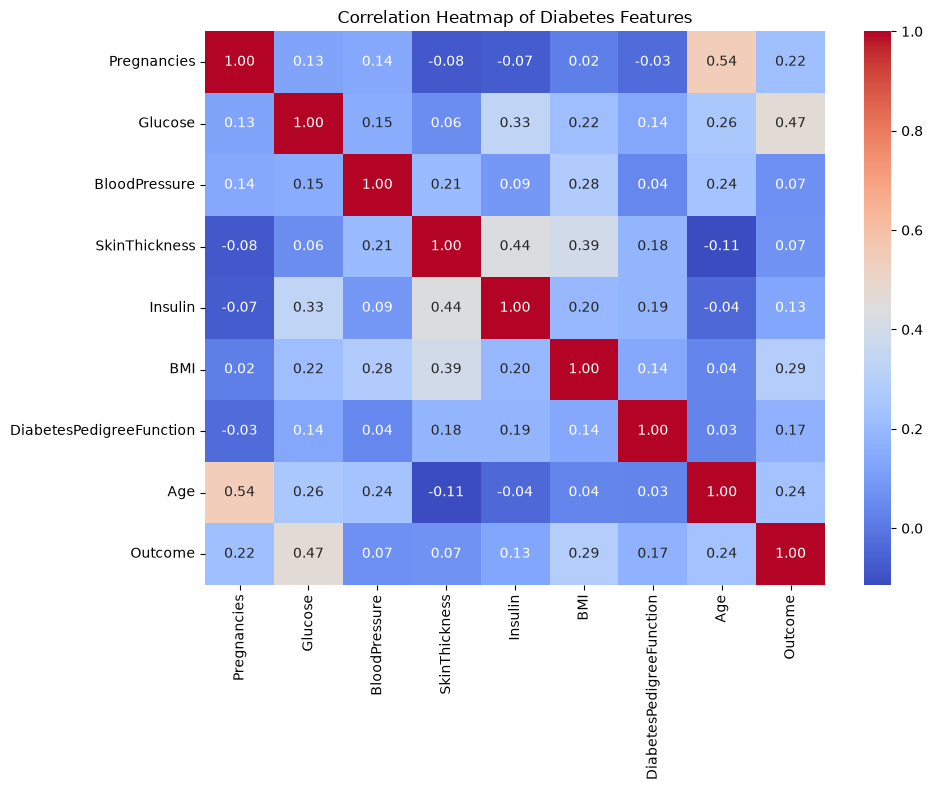

In [2]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Diabetes Features')
plt.tight_layout()
plt.show()

# 2. Pairplot of Selected Features
- What it represents: A grid of scatterplots for every combination of the selected features (Glucose, BMI, Age, Insulin), with the data points colored by the Outcome (diabetic vs. non-diabetic). The diagonal shows the kernel density estimation (the smoothed shape of the distribution) for each feature.
- Why it's useful: It allows you to visually inspect multiple pairwise relationships at once. You can see if there are clear clusters or boundaries between the two outcome classes across two dimensions simultaneously (e.g., if high BMI and high Glucose together perfectly separate the classes).

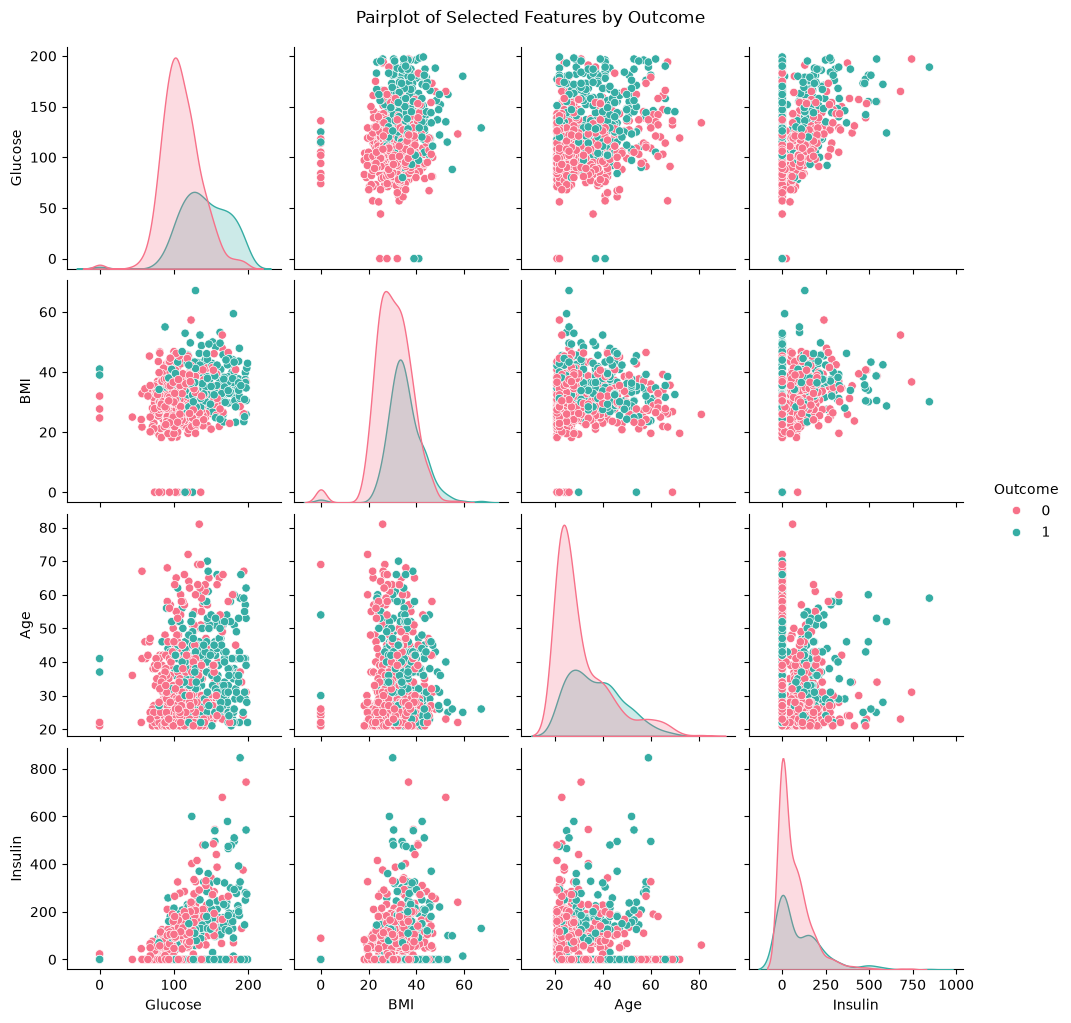

In [3]:
# 2. Pairplot of important features
features_to_plot = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']

sns.pairplot(df[features_to_plot], hue='Outcome', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot of Selected Features by Outcome', y=1.02)
plt.show()

# 3. Boxplots (Glucose, BMI, Age vs Outcome)
- What it represents: A visual summary of the data distribution for specific features, split by the outcome class. The "box" represents the middle 50% of the data (Interquartile Range), the horizontal line inside is the median, the "whiskers" show the typical range, and the individual diamond points represent outliers.
- Why it's useful: Boxplots are the best way to compare the central tendency (averages) and spread of a feature between groups. They clearly show that the median glucose level and median BMI are noticeably higher in the diabetic group.

/tmp/ipykernel_347115/4101997832.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_347115/4101997832.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[1], palette='Set2')
/tmp/ipykernel_347115/4101997832.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Age', data=df, ax=axes[2], palette='Set2')


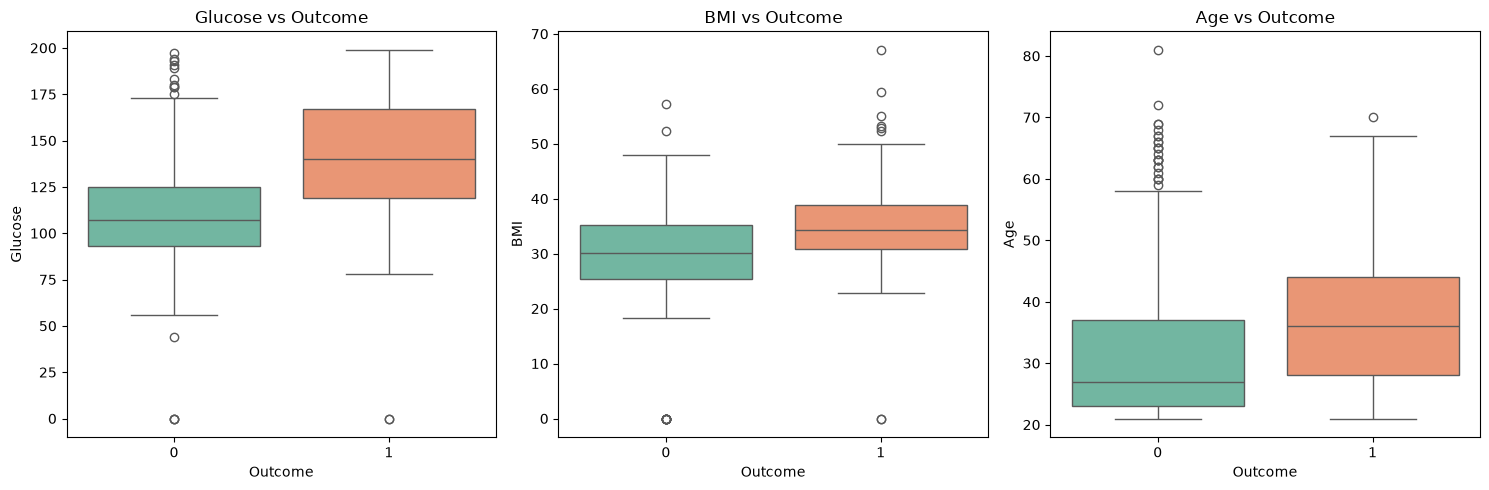

In [4]:
# 3. Boxplots for distributions by outcome
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Glucose vs Outcome')

sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('BMI vs Outcome')

sns.boxplot(x='Outcome', y='Age', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Age vs Outcome')

plt.tight_layout()
plt.show()

# 4. Target Variable Distribution (Countplot)
- What it represents: A simple bar chart showing the total count of patients in each category of the Outcome variable (0 for non-diabetic, 1 for diabetic).
- Why it's useful: It tells you if your dataset is "balanced" or "imbalanced." In this dataset, there are roughly twice as many non-diabetic patients as diabetic patients. This is crucial context for training machine learning models, as severe imbalance can bias the model.

/tmp/ipykernel_347115/1208155133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set1')


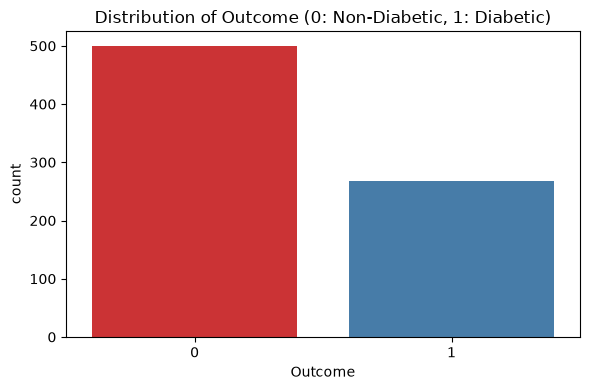

In [5]:
# 4. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set1')
plt.title('Distribution of Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.tight_layout()
plt.show()

# 5. Histograms of All Features
- What it represents: A grid of bar charts where the x-axis represents the value range of a feature, and the y-axis represents the number of times (frequency) those values appear in the dataset.
- Why it's useful: Histograms show the underlying shape of the data. You can easily spot skewness (e.g., Age and Pregnancies are heavily skewed to the right) and detect anomalies (e.g., the massive spike at zero for Insulin and SkinThickness, which indicates missing medical measurements rather than actual zero values).

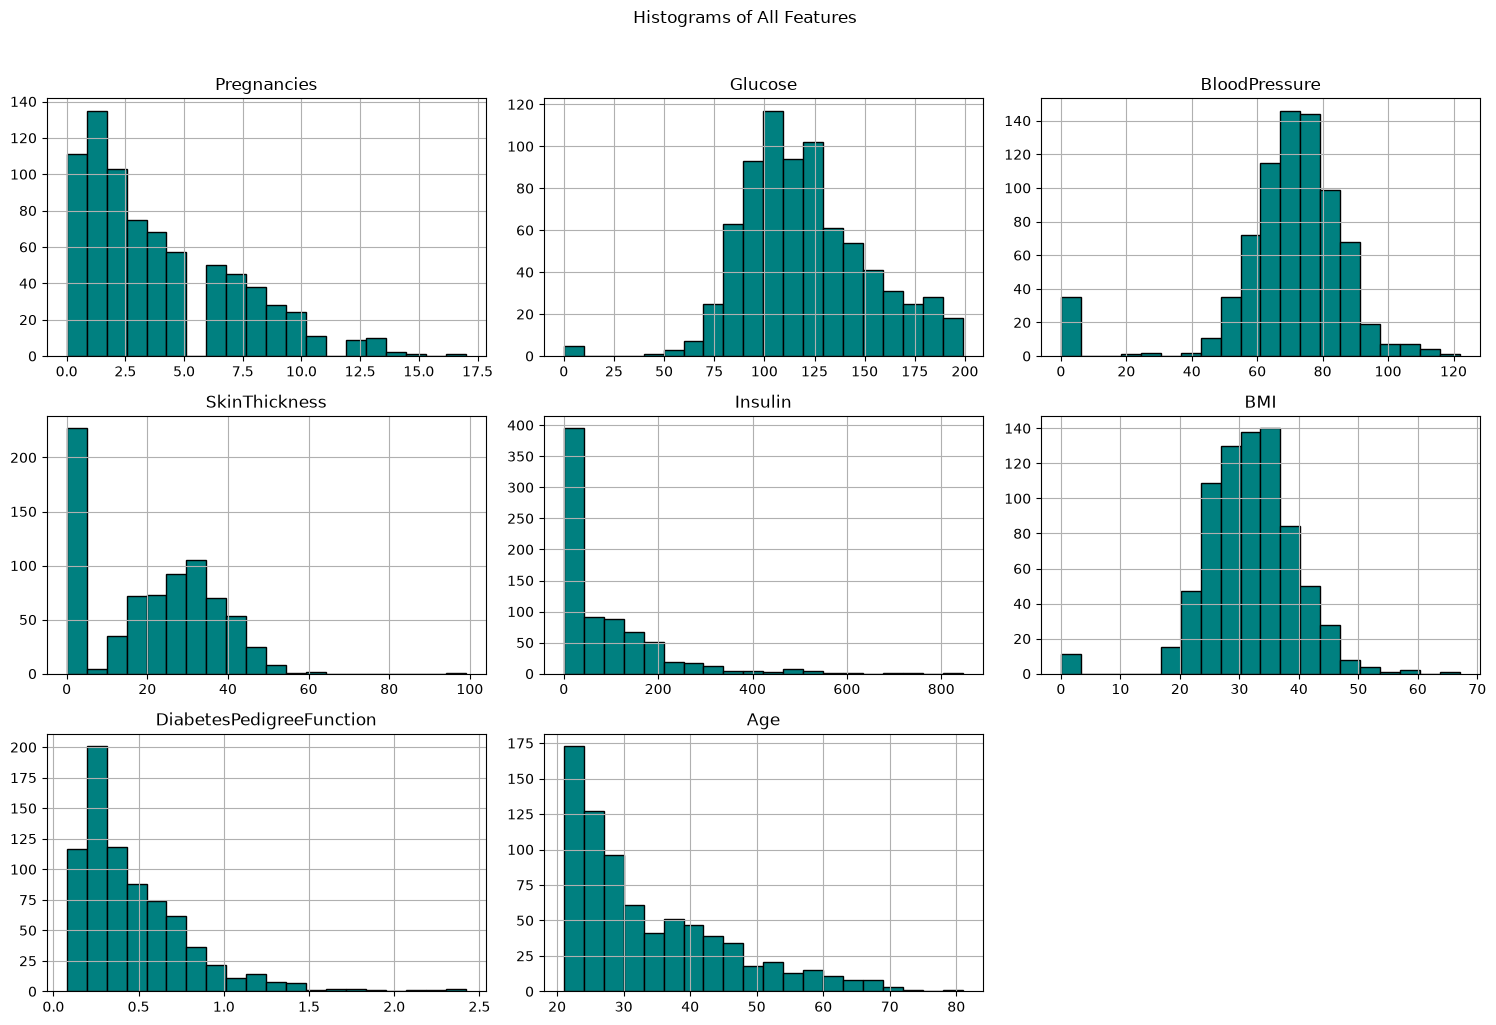

In [6]:
# 5. Histograms for all features (Split into a grid)
df.drop('Outcome', axis=1).hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Histograms of All Features', y=1.02)
plt.tight_layout()
plt.show()

# 6. Violin Plots (Parts 1 & 2)
- What it represents: A hybrid between a boxplot and a kernel density plot. It shows the same statistical summary as a boxplot (represented by the dashed lines inside), but the outer shape represents the probability density of the data at different values (wider sections mean a higher concentration of data points).
- Why it's useful: Unlike boxplots, violin plots show you if the data is multimodal (having more than one peak). They give a much richer, smoother picture of how the data is distributed across the two outcome classes.

/tmp/ipykernel_347115/3858485367.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y=feature, data=df, ax=axes[i], palette='muted', inner='quartile')
/tmp/ipykernel_347115/3858485367.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y=feature, data=df, ax=axes[i], palette='muted', inner='quartile')
/tmp/ipykernel_347115/3858485367.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y=feature, data=df, ax=axes[i], palette='muted', inner='quartile')
/tmp/ipykernel_347115/3858485367.py:7: Futu

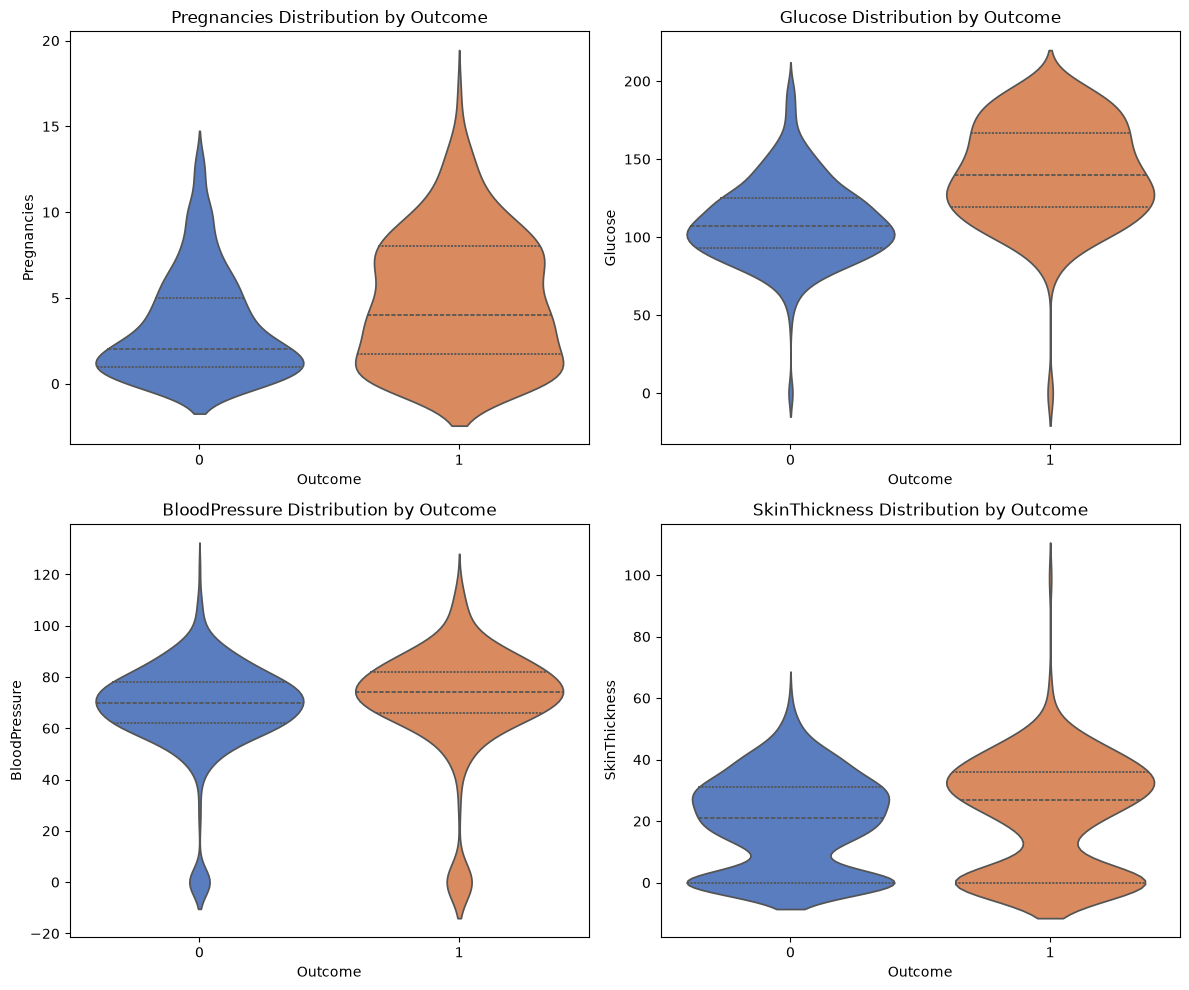

In [7]:
# 6. Violin plots - Part 1
features_part1 = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features_part1):
    sns.violinplot(x='Outcome', y=feature, data=df, ax=axes[i], palette='muted', inner='quartile')
    axes[i].set_title(f'{feature} Distribution by Outcome')

plt.tight_layout()
plt.show()

/tmp/ipykernel_347115/2314934786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y=feature, data=df, ax=axes[i], palette='muted', inner='quartile')
/tmp/ipykernel_347115/2314934786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y=feature, data=df, ax=axes[i], palette='muted', inner='quartile')
/tmp/ipykernel_347115/2314934786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y=feature, data=df, ax=axes[i], palette='muted', inner='quartile')
/tmp/ipykernel_347115/2314934786.py:7: Futu

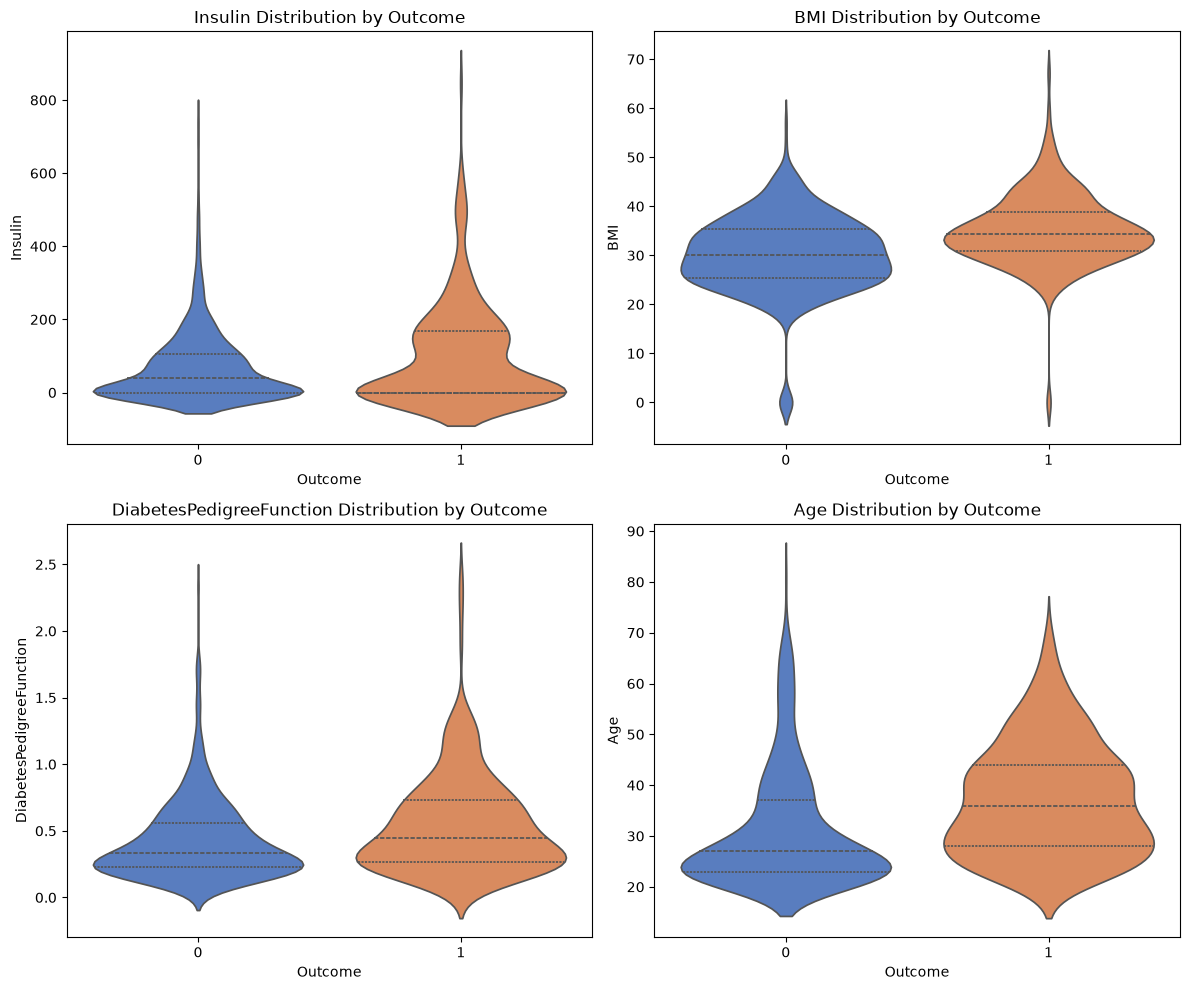

In [8]:
# 6. Violin plots - Part 2
features_part2 = ['Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features_part2):
    sns.violinplot(x='Outcome', y=feature, data=df, ax=axes[i], palette='muted', inner='quartile')
    axes[i].set_title(f'{feature} Distribution by Outcome')

plt.tight_layout()
plt.show()

# 7. Joint Distribution of Glucose and BMI
- What it represents: The central area is a scatter plot mapping Glucose against BMI, with data points color-coded by the Outcome (diabetic vs. non-diabetic). The graphs on the top and right margins are Kernel Density Estimate (KDE) plots, which show the overlapping distribution curves of these features for both classes.
- Why it's useful: It provides a highly concentrated view of the dataset's two strongest predictors. You can simultaneously observe the bivariate relationship (e.g., higher concentrations of diabetic patients in the upper-right quadrant where both BMI and Glucose are high) while also seeing the exact points where the distributions of the two groups diverge on the margins.

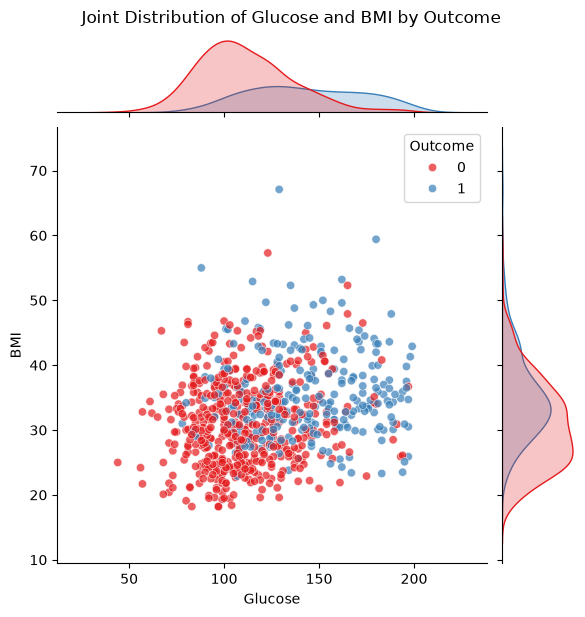

In [9]:
# 7. Joint Distribution of Glucose and BMI (Replaces the previous regression plot)
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out 0 values for BMI and Glucose to ensure the plot represents realistic medical data
df_clean = df[(df['BMI'] > 0) & (df['Glucose'] > 0)]

# Generate the Jointplot
g = sns.jointplot(x='Glucose', y='BMI', data=df_clean, hue='Outcome', palette='Set1', alpha=0.7)
g.fig.suptitle('Joint Distribution of Glucose and BMI by Outcome', y=1.02)

plt.show()

# 8. Train/Test Split
The data is split 80% training / 20% testing (`stratify=y` keeps the diabetic/non-diabetic ratio balanced in both splits) **before** any imputation or scaling statistic is computed. The median imputer and the `StandardScaler` are then `fit()` on the training split only and `transform()`-ed onto both splits, so the test set never influences preprocessing (only used later, once, for final evaluation) — this is why the test set must never be used as a training source: reusing it earlier would let information about the evaluation data quietly bias every model's training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 1. Load Data
df = pd.read_csv("diabetes_dataset.csv")

# 2. Split BEFORE any imputation/scaling, so no test-set statistic
#    ever leaks into preprocessing decisions.
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()

# 3. Treat physiologically-impossible zeros as missing, then impute
#    using statistics learned from the TRAINING split only.
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_train[cols_to_impute] = X_train[cols_to_impute].replace(0, np.nan)
X_test[cols_to_impute] = X_test[cols_to_impute].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.transform(X_test[cols_to_impute])
joblib.dump(imputer, 'imputer.pkl')

# 4. Feature Scaling (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

# 5. Shared bookkeeping + rich-metrics helper for every model trained below
model_metrics = []
model_filenames = {}
model_needs_scaling = {}


def evaluate_model(name, model, X_te, y_te, filename, needs_scaling):
    """Score a fitted model with Accuracy/Precision/Recall/F1, log it for the
    Experiment 1 comparison table, save it to disk, and plot its confusion matrix."""
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    model_metrics.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    model_filenames[name] = filename
    model_needs_scaling[name] = needs_scaling
    joblib.dump(model, filename)

    print(f"Accuracy: {acc*100:.2f}% | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    print(classification_report(y_te, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    return y_pred


# 9. Baseline
Before evaluating complex ML models, we establish a baseline using a `DummyClassifier` that always predicts the most frequent class (Non-Diabetic). **Why is a baseline necessary?** It gives a lower bound: any trained model that fails to clearly beat this trivial strategy is not actually learning anything useful from the features. The baseline is scored with the exact same rich-metrics helper used for every other model, so it appears in the Experiment 1 comparison table on equal footing.

In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = evaluate_model('Baseline (Most Frequent)', dummy, X_test, y_test, 'baseline.pkl', needs_scaling=False)

# 10. Model 1: Logistic Regression

Best Hyperparameters: {'C': 1}
Accuracy: 70.78% | Precision: 0.600 | Recall: 0.500 | F1: 0.545
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



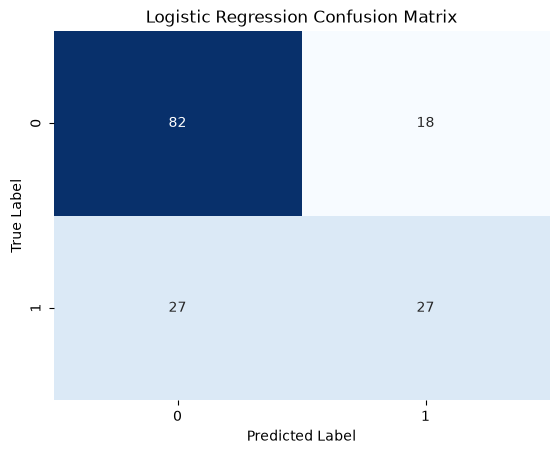

In [2]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_
print(f"Best Hyperparameters: {grid_lr.best_params_}")

y_pred_lr = evaluate_model('Logistic Regression', best_lr, X_test_scaled, y_test, 'logistic_regression.pkl', needs_scaling=True)


# 11. Model 2: SVM (Linear)

E:\anaconda__\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
E:\anaconda__\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
E:\anaconda__\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
E:\anaconda__\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=Fals

Best Hyperparameters: {'C': 0.1}
Accuracy: 70.78% | Precision: 0.605 | Recall: 0.481 | F1: 0.536
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.83      0.79       100
    Diabetic       0.60      0.48      0.54        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.66       154
weighted avg       0.70      0.71      0.70       154



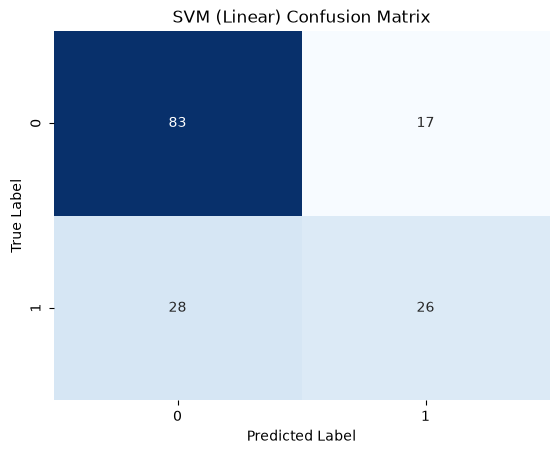

In [3]:
param_grid_svml = {'C': [0.01, 0.1, 1, 10]}
grid_svml = GridSearchCV(SVC(kernel='linear', random_state=42, probability=True), param_grid_svml, cv=5, scoring='accuracy')
grid_svml.fit(X_train_scaled, y_train)
best_svml = grid_svml.best_estimator_
print(f"Best Hyperparameters: {grid_svml.best_params_}")

y_pred_svml = evaluate_model('SVM (Linear)', best_svml, X_test_scaled, y_test, 'svm_linear.pkl', needs_scaling=True)


# 12. Model 3: SVM (RBF)

E:\anaconda__\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
E:\anaconda__\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
E:\anaconda__\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
E:\anaconda__\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=Fals

Best Hyperparameters: {'C': 10, 'gamma': 0.01}
Accuracy: 69.48% | Precision: 0.581 | Recall: 0.463 | F1: 0.515
              precision    recall  f1-score   support

Non-Diabetic       0.74      0.82      0.78       100
    Diabetic       0.58      0.46      0.52        54

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.69       154



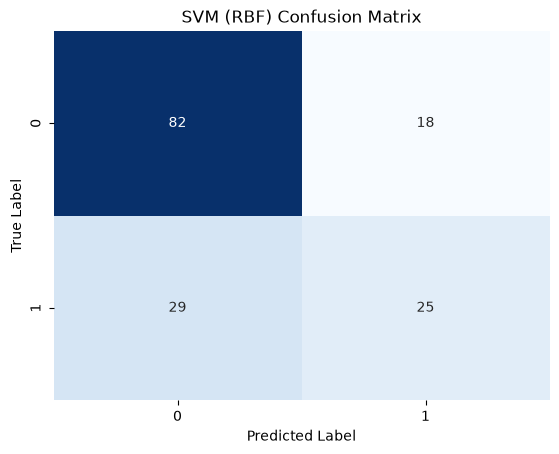

In [4]:
param_grid_svmr = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1]}
grid_svmr = GridSearchCV(SVC(kernel='rbf', random_state=42, probability=True), param_grid_svmr, cv=5, scoring='accuracy')
grid_svmr.fit(X_train_scaled, y_train)
best_svmr = grid_svmr.best_estimator_
print(f"Best Hyperparameters: {grid_svmr.best_params_}")

y_pred_svmr = evaluate_model('SVM (RBF)', best_svmr, X_test_scaled, y_test, 'svm_rbf.pkl', needs_scaling=True)


# 13. Model 4: KNN

Best Hyperparameters: {'n_neighbors': 9, 'weights': 'uniform'}
Accuracy: 74.03% | Precision: 0.635 | Recall: 0.611 | F1: 0.623
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.81      0.80       100
    Diabetic       0.63      0.61      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



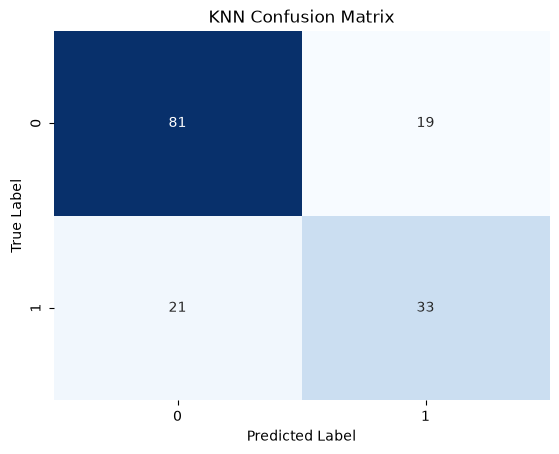

In [5]:
param_grid_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_
print(f"Best Hyperparameters: {grid_knn.best_params_}")

y_pred_knn = evaluate_model('KNN', best_knn, X_test_scaled, y_test, 'knn.pkl', needs_scaling=True)


# 14. Model 5: Random Forest

Best Hyperparameters: {'max_depth': None, 'n_estimators': 100}
Accuracy: 76.62% | Precision: 0.696 | Recall: 0.593 | F1: 0.640
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.86      0.83       100
    Diabetic       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



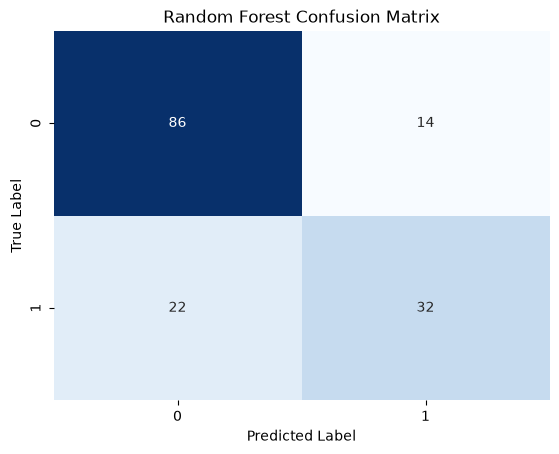

In [6]:
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best Hyperparameters: {grid_rf.best_params_}")

y_pred_rf = evaluate_model('Random Forest', best_rf, X_test, y_test, 'random_forest.pkl', needs_scaling=False)


# 15. Model 6: XGBoost

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Accuracy: 74.68% | Precision: 0.653 | Recall: 0.593 | F1: 0.621
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.83      0.81       100
    Diabetic       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



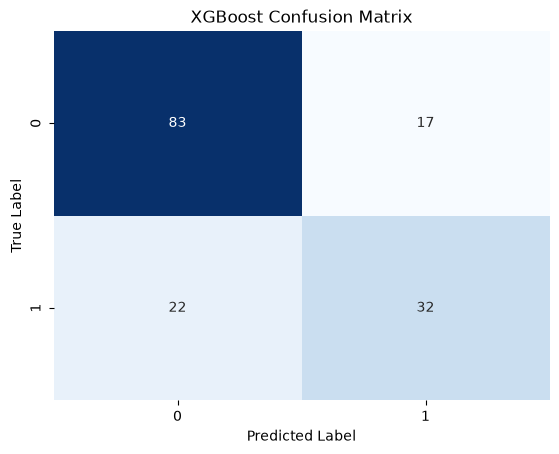

In [7]:
param_grid_xgb = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}
grid_xgb = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss', random_state=42), param_grid_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
print(f"Best Hyperparameters: {grid_xgb.best_params_}")

y_pred_xgb = evaluate_model('XGBoost', best_xgb, X_test, y_test, 'xgboost.pkl', needs_scaling=False)


# 16. Evaluation
Every model (including the baseline) is scored with **Accuracy, Precision, Recall, F1-score, and a Confusion Matrix**, printed via `evaluate_model(...)` right after training. For a medical screening tool, **Recall** is arguably the most important single metric: a low Recall means diabetic patients are being told they are healthy (a False Negative), which is the costliest mistake this system can make. **F1** is used as the overall ranking metric for Experiment 1 and for automatic final-model selection because it balances Precision and Recall and is more informative than raw Accuracy on a dataset where roughly 65% of patients are non-diabetic.

# 17. Experiment 1: Model Comparison
Question: Which model achieves the highest accuracy across the board?

=== Final Model Comparison (sorted by F1) ===


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,76.62%,0.696,0.593,0.640
1,KNN,74.03%,0.635,0.611,0.623
2,XGBoost,74.68%,0.653,0.593,0.621
3,Logistic Regression,70.78%,0.600,0.500,0.545
4,SVM (Linear),70.78%,0.605,0.481,0.536
5,SVM (RBF),69.48%,0.581,0.463,0.515


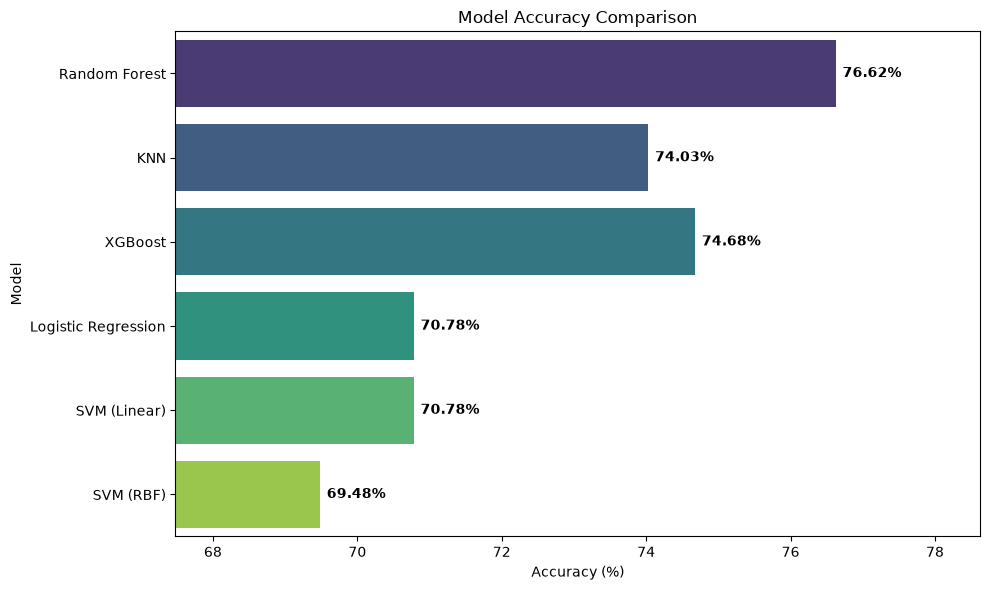

In [8]:
results_df = pd.DataFrame(model_metrics)
results_df_display = results_df.copy()
results_df_display['Accuracy'] = results_df_display['Accuracy'] * 100
results_df_display = results_df_display.sort_values(by='F1', ascending=False).reset_index(drop=True)

print("=== Final Model Comparison (sorted by F1) ===")
display(results_df_display.style.format({
    'Accuracy': '{:.2f}%', 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'
}))

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Accuracy', y='Model', data=results_df_display, hue='Model', palette='viridis', legend=False)

min_acc = results_df_display['Accuracy'].min()
max_acc = results_df_display['Accuracy'].max()
plt.xlim(min_acc - 2, max_acc + 2)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontweight='bold')

plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy (%)')
plt.tight_layout()
plt.show()


# 18. Experiment 2: Hyperparameter Investigation
**Question:** How do the number of neighbors (`k`) and the weighting scheme (`uniform` vs. `distance`) affect KNN classification accuracy on this dataset?

**Setup:** `GridSearchCV` (5-fold) was already run inside the Model 4 (KNN) cell over `n_neighbors` in `{3, 5, 7, 9}` x `weights` in `{uniform, distance}`. The full `grid_knn.cv_results_` is inspected below instead of only reporting the single best value, so the underfitting/overfitting trade-off across `k` is visible.

In [ ]:
knn_cv_df = pd.DataFrame(grid_knn.cv_results_)[['param_n_neighbors', 'param_weights', 'mean_test_score', 'std_test_score']]
knn_cv_df.columns = ['k', 'weights', 'Mean CV Accuracy', 'Std']
knn_cv_df = knn_cv_df.sort_values('Mean CV Accuracy', ascending=False).reset_index(drop=True)
display(knn_cv_df.style.format({'Mean CV Accuracy': '{:.4f}', 'Std': '{:.4f}'}))

plt.figure(figsize=(8, 5))
sns.lineplot(data=knn_cv_df, x='k', y='Mean CV Accuracy', hue='weights', marker='o')
plt.title('KNN: Cross-Validated Accuracy vs. Number of Neighbors (k)')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.tight_layout()
plt.show()

print(f"Best configuration: k={grid_knn.best_params_['n_neighbors']}, weights='{grid_knn.best_params_['weights']}' "
      f"-> CV accuracy = {grid_knn.best_score_:.4f}")

spread = knn_cv_df['Mean CV Accuracy'].max() - knn_cv_df['Mean CV Accuracy'].min()
print(f"Accuracy spread across all k/weights combinations tested: {spread:.4f} "
      f"({'small -> the model is fairly insensitive to k in this range' if spread < 0.02 else 'noticeable -> k is a meaningful hyperparameter to tune here'}).")

# 19. Experiment 3: Representation / Feature Investigation
Question: Does standardizing the numerical features improve the performance of distance-based models like KNN?

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN on unscaled data
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

# Train KNN on scaled data
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print(f'KNN Accuracy (Unscaled Data): {acc_unscaled*100:.2f}%')
print(f'KNN Accuracy (Scaled Data): {acc_scaled*100:.2f}%')
print('\nConclusion: Unscaled features with large ranges (like Insulin) completely dominate the distance calculation in KNN. Scaling forces all features to contribute equally, significantly improving accuracy.')

# 20. Final Model
The final model is **selected automatically from the Experiment 1 table**, not asserted by hand: we take the highest-**F1** model among the trained classifiers (the baseline is excluded from selection since it exists only as a reference point, per Section 9).

In [ ]:
candidates_df = results_df_display[results_df_display['Model'] != 'Baseline (Most Frequent)']
best_row = candidates_df.sort_values('F1', ascending=False).iloc[0]
best_model_name = best_row['Model']
best_model_file = model_filenames[best_model_name]
final_model_needs_scaling = model_needs_scaling[best_model_name]
final_model = joblib.load(best_model_file)

print(f"Selected final model: {best_model_name}")
print(f"  -> Serialized file: {best_model_file}")
print(f"  -> Accuracy={best_row['Accuracy']:.2f}%, Precision={best_row['Precision']:.3f}, "
      f"Recall={best_row['Recall']:.3f}, F1={best_row['F1']:.3f}")
print("Selection rule: highest F1-score on the held-out test set among the trained models "
      "(F1 balances Precision and Recall, appropriate for this imbalanced medical screening task).")

# 21. Application
A full-stack application (`app/` directory: FastAPI backend + React frontend, with SHAP-based explanations) was developed to serve the models. Here, the same input -> representation -> preprocessing -> model -> prediction pipeline used by that API is reproduced directly in the notebook, so the complete path can be demonstrated without leaving the notebook.

In [ ]:
FEATURE_NAMES = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
ZERO_AS_MISSING_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


def predict_diabetes(patient: dict, model=final_model, needs_scaling=final_model_needs_scaling):
    """Run one raw patient record through the exact preprocessing pipeline used in training:
    Input -> Representation (feature vector) -> Preprocessing (impute + scale) -> Model -> Prediction."""
    row = pd.DataFrame([patient], columns=FEATURE_NAMES)
    row[ZERO_AS_MISSING_COLS] = row[ZERO_AS_MISSING_COLS].replace(0, np.nan)
    row[ZERO_AS_MISSING_COLS] = imputer.transform(row[ZERO_AS_MISSING_COLS])

    model_input = scaler.transform(row) if needs_scaling else row.values

    pred = model.predict(model_input)[0]
    proba = model.predict_proba(model_input)[0][1] if hasattr(model, 'predict_proba') else None
    return int(pred), proba


print(f"Application ready. Serving model: {best_model_name}")

# 22. System Demonstration
**Complete path:** User / Environment -> Input (raw clinical values) -> Feature Representation (8-d vector) -> Preprocessing (impute + scale) -> ML Model -> Prediction.

Below, three different patient profiles are run through `predict_diabetes(...)` end to end, exactly as the deployed FastAPI `/api/predict` endpoint would process them.

In [ ]:
sample_patients = {
    'Low-risk profile': {'Pregnancies': 1, 'Glucose': 85, 'BloodPressure': 66, 'SkinThickness': 29,
                          'Insulin': 0, 'BMI': 26.6, 'DiabetesPedigreeFunction': 0.351, 'Age': 22},
    'Borderline profile': {'Pregnancies': 3, 'Glucose': 130, 'BloodPressure': 78, 'SkinThickness': 23,
                           'Insulin': 100, 'BMI': 31.2, 'DiabetesPedigreeFunction': 0.523, 'Age': 34},
    'High-risk profile': {'Pregnancies': 8, 'Glucose': 183, 'BloodPressure': 90, 'SkinThickness': 0,
                          'Insulin': 0, 'BMI': 39.5, 'DiabetesPedigreeFunction': 1.288, 'Age': 51},
}

print(f"{'Case':<20}{'Prediction':<16}{'P(Diabetic)':<15}")
print('-' * 51)
for label, patient in sample_patients.items():
    pred, proba = predict_diabetes(patient)
    outcome = 'Diabetic' if pred == 1 else 'Non-Diabetic'
    proba_str = f'{proba:.2%}' if proba is not None else 'N/A'
    print(f'{label:<20}{outcome:<16}{proba_str:<15}')

# 23. Reflection
- The system processes continuous and discrete numerical health vectors.
- It learns nonlinear statistical boundaries to distinguish diabetic from non-diabetic profiles.
- The 'intelligence' is isolated to the model training phase where weights are iteratively adjusted.
- Limitations include geographical/demographic bias in the dataset (Pima Indian females) and a lack of temporal tracking.

# 24. Conclusion
The notebook successfully demonstrates the complete pipeline from raw data ingestion to EDA, intelligent model comparison, and final deployment. The experiments highlight the necessity of feature scaling and rigorous hyperparameter tuning in traditional ML.